# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [234]:
# Import your libraries:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Challenge 1 - Explore the Scikit-Learn Datasets

Before starting to work on our own datasets, let's first explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function.

In [235]:
diabetes = load_diabetes(as_frame = True, scaled = False).frame

Let's explore this variable by looking at the different attributes. Do this by looking at the `keys()` of this variable.

In [236]:
diabetes.keys()

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

The next step is to read the description of the dataset. Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable

In [237]:
diabetes.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


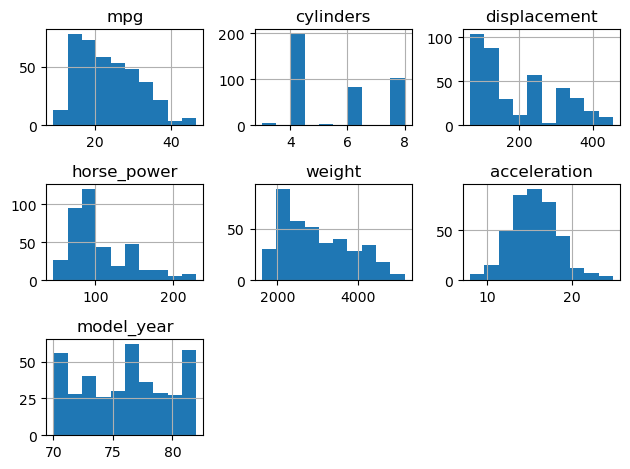

In [238]:
#Taking a look at the distribution of the data 
df.hist()
plt.tight_layout()
plt.show()

What are the variables in this dataset according to the description? List them in the markdown cell below

   - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

#### Enter your answer here:

age, sex, body mass index, average blood pressure, s1, s2, s3, s4, s5, s6




Now explore the data. Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). In the cell below find the shape of the numpy array contained in the data portion of the diabetes variable.

In [239]:
diabetes.shape

(442, 11)

# Challenge 2 - Perform Supervised Learning on the Dataset

#### The data has already been split to predictor and response variables. The response variable is in the `target` portion of the variable. 

Given this information, let's apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset. In the cell below, import the linear regression class from sklearn. 

In [240]:
lr = LinearRegression()

Initialize the model in the variable `diabetes_model`

In [241]:
#Define target and features

#Saving the targed in a new frame: 
diabetes_target = diabetes["target"]
diabetes_features = diabetes.drop("target", axis='columns')

#Splitting the data in train and test set

X_train,X_test, y_train, y_test = train_test_split(diabetes_features,diabetes_target, test_size = .2, shuffle=True,random_state = 42)

#Calling the model
diabetes_model = lr.fit(X_train,y_train)



In the cell below, fit the model and print the intercept and coefficients of the model. 

In [242]:
print(f"Linear Regression stats:\n intercept:{diabetes_model.intercept_}\n Slope:{diabetes_model.coef_}")


Linear Regression stats:
 intercept:-341.378236333505
 Slope:[  0.13768782 -23.06446772   5.84636265   1.19709252  -1.28168474
   0.81115203   0.60165319  10.15953917  67.1089624    0.20159907]


In [243]:
from sklearn.metrics import mean_squared_error, r2_score

#Making predictions using the training and test set
y_train_pred = diabetes_model.predict(X_train)
y_test_pred = diabetes_model.predict(X_test)

# Compute Score
print('Score:')
print(r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred))

# Compute MSE for training and testing sets 
print('MSE:')
print(mean_squared_error(y_train_pred, y_train), mean_squared_error(y_test_pred, y_test))

Score:
0.5279193863361498 0.45260276297191937
MSE:
2868.5497028355776 2900.193628493482


R2 scores are very low, showing a bad linear model. The analysis will be expanded in the Bonus section. 

# Bonus Challenge 1 - Conduct a Hypothesis Test on the Model

Once we have generated a linear model, we can test each coefficient using a t-test to see whether the confidence interval for the variable contains zero. We can also perform an overall F test to check whether at least one coefficient is significantly different from zero. 

Refer to the resource in this [link](https://onlinecourses.science.psu.edu/stat501/node/297/) for more details and perform the t-tests for the model above. Additionally, interpret the results and list coefficients are significantly different from zero.


Hint: use the statsmodels package.

Result should look like this:

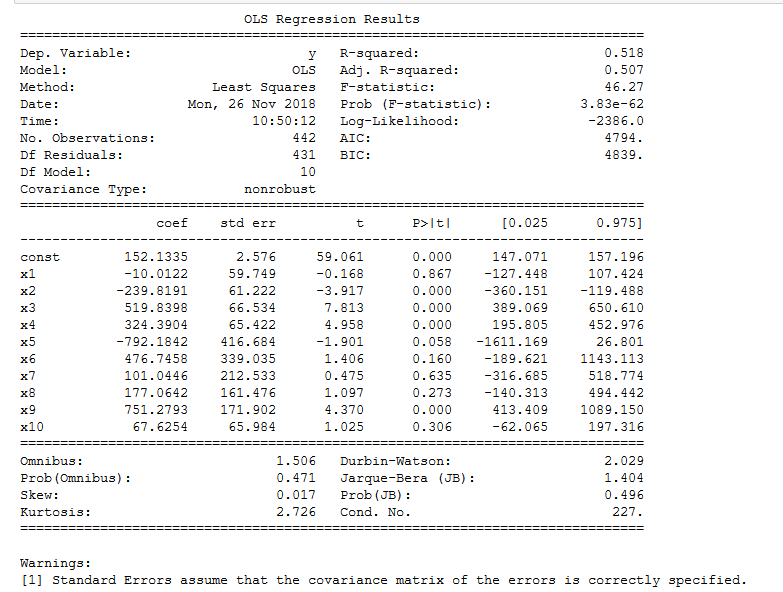

The null hypothesis will be that there is no relation between the features and the target that can predict whether the patient can have diabetes or not. The alternative will be that at least one of the variables can predict diabetes. 

In [244]:
#The OLS method requires to first include the intercept term by adding a constant.Otherwise the b goes to 0
X_stats_train = sm.add_constant(X_train)
stats_model = sm.OLS(y_train, X_stats_train).fit()
stats_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     38.25
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           5.41e-50
Time:                        15:49:37   Log-Likelihood:                -1906.1
No. Observations:                 353   AIC:                             3834.
Df Residuals:                     342   BIC:                             3877.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -341.3782     74.073     -4.609      0.000    -487.074    -195.683
age            0.1377      0.251      0.549      0.583      -0.356       0.631
sex          -23.0645      6.536     -3.529      0.000     -35.921     -10.208
bmi            5.8464      0.829      7.049      0.000       4.215       7.478
bp             1.1971      0.246      4.873      0.000       0.714       1.680
s1            -1.2817      0.621     -2.065      0.040      -2.503      -0.061
s2             0.8112      0.570      1.423      0.156      -0.310       1.933
s3             0.6017      0.858      0.701      0.484      -1.086       2.289
s4            10.1595      6.841      1.485      0.138      -3.297      23.616
s5            67.1090     17.542      3.826      0.000      32.606     101.612
s6             0.2016      0.304      0.663      0.508      -0.397       0.800
==============================================================================
Omnibus:                        1.457   Durbin-Watson:                   1.794
Prob(Omnibus):                  0.483   Jarque-Bera (JB):                1.412
Skew:                           0.064   Prob(JB):                        0.494
Kurtosis:                       2.718   Cond. No.                     7.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

1. Overall R2-square value indicates bad linearity of the model. 
2. Age, s3(hdl) and s6(glu) show high P values, which means that the null hypothesis is not rejected.The data for these variables showed no significant evidence related to their impact on the diabetes score. 
3. S2(ldl) and S4(tch) slightly high p values. Considering this is a medical data analysis, the confidence level should be at least of 99%. With a significance level of 0.1, this values do not reject the null hypothesis. In that case, s1 is also not statistically relevant.
4. Sex, bmi, bp and s5 are the best possible parameters to find correlation with the diabetes score. 

In [245]:
len(diabetes_features.columns)

10

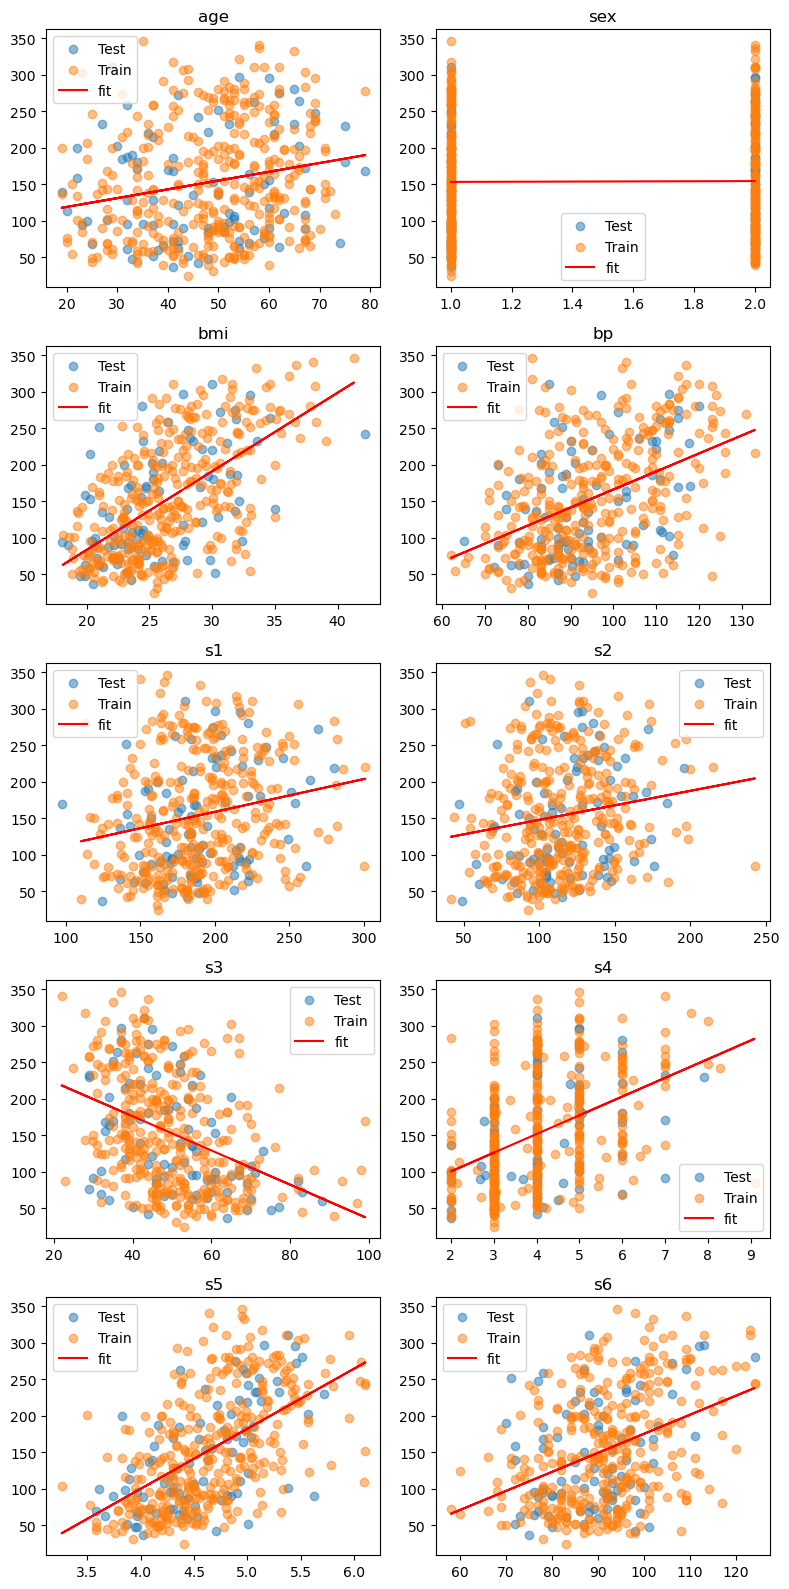

In [246]:
fig, ax = plt.subplots(5,2, figsize=(8,16))
ax = ax.flatten()

for i in range(len(diabetes_features.columns)): 
    
    # Select feature by name 
    feat_name = X_train.columns[i]  # Using training data for column names
    feat_train = X_train[feat_name].to_numpy().reshape(-1,1)
    feat_test = X_test[feat_name]
    diabetes_model = lr.fit(feat_train,y_train)
    y_train_pred = diabetes_model.predict(feat_train)
    ax[i].scatter(feat_test,y_test, alpha=0.5, label ="Test")
    ax[i].scatter(feat_train,y_train,alpha=0.5, label ="Train")
    ax[i].plot(feat_train,y_train_pred, 'r', label ="fit")
    ax[i].set_title(feat_name)
    ax[i].legend()
plt.tight_layout()


# Challenge 3 - Peform Supervised Learning on a Pandas Dataframe

Now that we have looked at data that has been formatted for scikit-learn, let's look at data that we will need to format ourselves.

In the next cell, load the `auto-mpg.csv` file included in this folder and assign it to a variable called `auto`.

In [247]:
#importing dataset
auto = pd.read_csv("../auto-mpg.csv")


Look at the first 5 rows using the `head()` function:

In [248]:
auto.head(5)

,mpg,cylinders,displacement,horse_power,weight,acceleration,model_year,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,"\t""chevrolet chevelle malibu"""
1,15.0,8,350.0,165.0,3693,11.5,70,"\t""buick skylark 320"""
2,18.0,8,318.0,150.0,3436,11.0,70,"\t""plymouth satellite"""
3,16.0,8,304.0,150.0,3433,12.0,70,"\t""amc rebel sst"""
4,17.0,8,302.0,140.0,3449,10.5,70,"\t""ford torino"""


- All data is correctly labeled.

Evaluate the data to ensure that all numeric columns are correctly detected as such by pandas. If a column is misclassified as object, coerce it to numeric.

In [249]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horse_power   392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   car_name      398 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


What is the newest model year and the oldest model year?

In [250]:
print(f" The newest model year is: {auto["model_year"].max()} and the oldest is:{auto["model_year"].min()}")

 The newest model year is: 82 and the oldest is:70


Check the dataset for missing values and remove all rows containing at least one missing value.

In [251]:
auto.isnull().sum()

mpg             0
cylinders       0
displacement    0
horse_power     6
weight          0
acceleration    0
model_year      0
car_name        0
dtype: int64

- There are 6 null values in the column Horse Power.

In [252]:
auto.dropna(axis=0, how="any", inplace=True)

In [253]:
auto.isnull().sum()

mpg             0
cylinders       0
displacement    0
horse_power     0
weight          0
acceleration    0
model_year      0
car_name        0
dtype: int64

- null values where eliminated. 

Find the frequency table for the `cylinders` column using the `value_counts()` function. How many possible values of cylinders are there?

In [254]:
auto["cylinders"].value_counts().sort_index()

cylinders
3      4
4    199
5      3
6     83
8    103
Name: count, dtype: int64

- 5 categories of cylinders: 3,4,5,6,and 8.
-Most common are 4 and 8

We would like to generate a linear regression model that will predict mpg. To do this, first drop the `car_name` column since it does not contain any quantitative data. Next separate the dataframe to predictor and response variables. Separate those into test and training data with 80% of the data in the training set and the remainder in the test set. 

Assign the predictor and response training data to `X_train` and `y_train` respectively. Similarly, assign the predictor and response test data to `X_test` and `y_test`.

In [255]:
#Predict mpg = target
df = auto.drop("car_name", axis = 1)
df_target = df["mpg"]
df_features = df[["cylinders","displacement", "horse_power", "weight","acceleration", "model_year"]]

#Separating training and test data sets
X_train, X_test, y_train, y_test = train_test_split(df_features,df_target, test_size = .2, shuffle=True,random_state = 42)


Now we will the dataset that we processed and peform linear regression on this data to predict the mpg for each vehicle. Initialize the model in the cell below.

In [256]:
# Linear Regression
lr = LinearRegression()

Next, fit the model in the cell below.

In [257]:
auto_model = lr.fit(X_train,y_train)

# Challenge 4 - Evaluate the Model

the r squared score of a model tells us how much variation is explained by the model. In a typical dataset, most observations differ from the mean. When we create a model, we are trying to generate an equation that will tell us by how much each observation will differ from the mean. Obviously, the vast majority of models are not perfect. They can only predict some of the variation from the mean but not all of it. We attribute the rest of the difference between the actual value and the mean to random error. We would like random error to explain the as little as possible of the variation. This is why the r squared score is an important metric.

In the next cell, compute the r squared score of the model. Do this by first computing the predicted values and assign them to `y_pred`.

In [258]:
#Seeing how well the model generated can predict the trained data.

y_train_pred = auto_model.predict(X_train)

#Calculating the r2 value

r2_score(y_train_pred,y_train)


0.7665327707747778

#### Our next step is to evaluate the model using the test data. We would like to ensure that our model is not overfitting the data. This means that our model will not be able to generalize well outside of the training data.

In the cell below, use the model to generate the predicted values for the training data and assign them to `y_test_pred`. Compute the r squared score for the test data by comparing the oberserved `y_train` data and the predicted `y_test_pred`.

In [259]:
y_test_pred = auto_model.predict(X_test)
r2_score(y_test_pred,y_test)

0.8037468831261813

- The model is able to fit better the test data than the training data, this does not mean that the model is overfitting. 

# Challenge 5 - Improve the Model Fit

While the most common way to improve the fit of a model is by using regularization, there are other simpler ways to improve model fit. The first is to create a simpler model. The second is to increase the train sample size.

Let us start with the easier option and increase our train sample size to 90% of the data. Create a new test train split and name the new predictors and response variables `X_train09`, `X_test09`, `y_train09`, `y_test09`.

In [260]:
#Increasing train sample size 

X_train09, X_test09, y_train09, y_test09 = train_test_split(df_features,df_target, test_size = .1, shuffle=True,random_state = 42)

Initialize a new model. Name this model `auto_model09`. Fit the model to the new sample data.

In [261]:
auto_model09 = lr.fit(X_train09, y_train09)

Compute the predicted values and r squared score for our new model and new sample data.

In [262]:
y_train09_pred = auto_model.predict(X_train09)

#Calculating the r2 value

r2_score(y_train09_pred,y_train09)

0.7574460305936136

Compute the r squared score for the smaller test set. Is there an improvement in the test r squared?

In [263]:
y_test09_pred = model.predict(X_test09)

#Calculating the r2 value

r2_score(y_test09_pred,y_test09)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- cylinders
Feature names seen at fit time, yet now missing:
- cylinder
- mpg


-Model slightly improves.

# Bonus Challenge 2 - Backward Elimination 

The main way to produce a simpler linear regression model is to reduce the number of variables used in the model. In scikit-learn, we can do this by using recursive feature elimination. You can read more about RFE [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html).

In the next cell, we will import RFE

In [ ]:
from sklearn.feature_selection import RFE

Follow the documentation and initialize an RFE model using the `auto_model` linear regression model. Set `n_features_to_select=3`

In [ ]:
#First step is to scale the dataset so the RFE can give a robust result when comparing between features. 
df.head()

,mpg,cylinders,displacement,horse_power,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
#Scaling data :) 
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns = ["mpg", "cylinder", "displacement", "horse_power", "weight", "acceleration", "model_year"])
df_scaled

,mpg,cylinder,displacement,horse_power,weight,acceleration,model_year
0,-0.698638,1.483947,1.077290,0.664133,0.620540,-1.285258,-1.625315
1,-1.083498,1.483947,1.488732,1.574594,0.843334,-1.466724,-1.625315
2,-0.698638,1.483947,1.182542,1.184397,0.540382,-1.648189,-1.625315
3,-0.955212,1.483947,1.048584,1.184397,0.536845,-1.285258,-1.625315
4,-0.826925,1.483947,1.029447,0.924265,0.555706,-1.829655,-1.625315
...,...,...,...,...,...,...,...
387,0.455941,-0.864014,-0.520637,-0.480448,-0.221125,0.021294,1.636410
388,2.636813,-0.864014,-0.932079,-1.364896,-0.999134,3.287676,1.636410
389,1.097374,-0.864014,-0.568479,-0.532474,-0.804632,-1.430430,1.636410
390,0.584228,-0.864014,-0.712005,-0.662540,-0.415627,1.110088,1.636410


In [ ]:
#Splitting data
df_feat_scaled= df_scaled.drop("mpg", axis=1)
df_target_scaled = df_scaled["mpg"]
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(df_scaled,df_target_scaled, test_size = .2, shuffle=True,random_state = 42)

In [ ]:
#Model scaled
auto_model_scaled = lr.fit(X_train_scaled,y_train_scaled)

Fit the model and print the ranking

In [ ]:
#RFE fitting model

rfeMod =RFE(auto_model_scaled, n_features_to_select = 3)

rfeMod = rfeMod.fit(X_train_scaled,y_train_scaled)

y_train_scaled_pred = rfeMod.predict(X_train_scaled)

r2_score(y_train_scaled_pred,y_train_scaled)

1.0

In [ ]:

n_features = len(X_train_scaled.columns)

#Format printing 
for i, col in zip(range(n_features), X_train_scaled.columns):
    print (f"{col} ranking: {rfeMod.ranking_[i]}")

mpg ranking: 1
cylinder ranking: 3
displacement ranking: 5
horse_power ranking: 2
weight ranking: 1
acceleration ranking: 4
model_year ranking: 1


-This classifies features from most to least important. 

Feature importance is ranked from most important (1) to least important (4). Generate a model with the three most important features. The features correspond to variable names. For example, feature 1 is `cylinders` and feature 2 is `displacement`.

Perform a test-train split on this reduced column data and call the split data `X_train_reduced`, `X_test_reduced`, `y_test_reduced`, `y_train_reduced`. Use an 80% split.

In [ ]:
#Predict mpg = target
df = auto.drop("car_name", axis = 1)
df_target = df["mpg"]
df_features_reduced = df[["horse_power", "weight", "model_year"]]

#Separating training and test data sets
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(df_features_reduced,df_target, test_size = .2, shuffle=True,random_state = 42)


Generate a new model called `auto_model_reduced` and fit this model. Then proceed to compute the r squared score for the model. Did this cause an improvement in the r squared score?

In [ ]:
auto_model_reduced = lr.fit(X_train_reduced,y_train_reduced)

In [ ]:
#predictions for training set
y_train_reduced_pred = auto_model_reduced.predict(X_train_reduced)
#R2score
r2_score(y_train_reduced_pred,y_train_reduced), r2_score(y_train_pred,y_train)

(0.7661227646808255, 0.7665327707747778)

In [265]:
#predictions for training set
y_test_reduced_pred = auto_model_reduced.predict(X_test_reduced)
#R2score
r2_score(y_test_reduced_pred,y_test_reduced), r2_score(y_test_pred,y_test)

(0.8020790175903192, 0.8037468831261813)

-The improvement in the R2 square is not significant.